# Comparative Evaluation of LLM Models — Electronic Health Record (EHR) Auditor

This notebook compares candidate LLM models (Qwen2.5-3B, Phi-4-mini-instruct e Llama 3.2 3B) using the endpoint already integrated with the system.

**Prerequisites:**
- The system endpoint running locally (LM Studio + your backend)
- Structured ground truth in `data/gabarito.csv`
- Test records in `data/prontuarios.json`


In [1]:
%pip install requests pandas numpy scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


## 1. Setup and imports

In [2]:
import json
import re
import time
import requests
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Paths
DATA_DIR = Path('data')
RESULTS_DIR = DATA_DIR / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Producer URL
PRODUCER_URL = "http://localhost:3001"

# Full list of candidate models (general reference for the study)
ALL_MODELS = [
    "qwen2.5-3b-instruct",
    "phi-4-mini-instruct",
    "llama-3.2-3b-instruct",
]

N_REPETITIONS = 1
SEED = 42

# Auditable fields per section.
# NOTE: these section/field keys ("secao_a", "hda", "escala_braden", ...) are
# NOT translated — they must match the exact keys returned by the backend's
# audit_data JSON payload, so changing them would break the lookup below.
AUDITABLE_FIELDS = {
    "secao_a": [
        "diagnostico_internacao",
    ],
    "secao_b_anamnese": [
        "hda", "hd_cid", "ap_app", "af", "exame_fisico", "cd", "criacao_anamnese",
    ],
    "secao_b_evolucao": [
        "hd_cid", "exame_fisico", "procedimentos_condutas_queixas", "frequencia_diaria",
    ],
    "secao_c": [
        "diagnostico_cid", "descricao_procedimento", "descricao_tecnica", "uso_opme",
    ],
    "secao_d_anamnese": [
        "motivo_internacao", "ap_app", "af", "exame_fisico",
        "escala_braden", "escala_morse", "cd", "criacao_anamnese",
    ],
    "secao_d_evolucao": [
        "motivo_internacao", "exame_fisico", "condutas",
        "escala_braden", "escala_morse", "curativo", "criacao_evolucao",
    ],
}

def clean_id(value):
    return re.sub(r'\D', '', str(value))

## 2. Load ground truth and test records

The ground truth needs to be in a structured format: one row per (record, field), with the expected label.

Expected format of the `gabarito.csv` file:

| record | section | field | professional category | record type | result | description missing | total conformity |
|---|---|---|---|---|---|---|---|
| 85826536 | secao_d_evolucao | escala_braden | ENFERMAGEM | Evolução | ausente | Escala de Braden não preenchida na evolução de enfermagem | Parcialmente Conforme | 
| 85826536 |  |  |  | | | | Conforme |

Where '' is `conforme` (the information is correctly recorded / compliant) or `ausente` (missing/not recorded).


In [3]:
ground_truth = pd.read_csv(DATA_DIR / 'gabarito.csv')
ground_truth['record'] = ground_truth['record'].apply(clean_id)

print(f"Total ground truth rows: {len(ground_truth)}")
print(f"Unique records: {ground_truth['record'].nunique()}")

conforme_records = ground_truth[ground_truth['total conformity'] == 'Conforme']['record'].nunique()
parcial_records = ground_truth[ground_truth['total conformity'] == 'Parcialmente Conforme']['record'].nunique()

print(f"Records Conforme: {conforme_records}")
print(f"Records Parcialmente Conforme: {parcial_records}")

ground_truth.head()

Total ground truth rows: 35
Unique records: 11
Records Conforme: 2
Records Parcialmente Conforme: 9


,record,section,field,professional category,record type,result,description missing,total conformity
0,94098934,secao_c,diagnostico_cid,MEDICINA,Cirúrgico,ausente,CID do diagnóstico cirúrgico não preenchido no...,Parcialmente Conforme
1,94098934,secao_d_anamnese,af,ENFERMAGEM,Anamnese,ausente,Antecedentes familiares não registrados na ana...,Parcialmente Conforme
2,99692381,NaN,NaN,NaN,NaN,NaN,NaN,Conforme
3,20981529,secao_b_anamnese,exame_fisico,MEDICINA,Anamnese,incompleta,Exame físico sem avaliação de ACV e ABD,Parcialmente Conforme
4,20981529,secao_c,diagnostico_cid,MEDICINA,Cirúrgico,ausente,CID do diagnóstico cirúrgico não preenchido,Parcialmente Conforme


In [4]:
N_PATIENTS = 11

with open(DATA_DIR / 'prontuarios.json', encoding='utf-8') as f:
    all_records = json.load(f)

# Only picks patients that exist in the ground truth
ground_truth_pids = set(ground_truth['record'].unique())

unique_records = []
for record_entry in all_records:
    pid = clean_id(record_entry.get('Prontuário', ''))
    if pid in ground_truth_pids and pid not in unique_records:
        unique_records.append(pid)
        if len(unique_records) == N_PATIENTS:
            break

test_records = [
    r for r in all_records
    if clean_id(r.get('Prontuário', '')) in unique_records
]

print(f"Sample reduced to: {len(unique_records)} unique records (all in ground truth).")
print(f"Total entries that will be sent to the endpoint: {len(test_records)}")

Sample reduced to: 11 unique records (all in ground truth).
Total entries that will be sent to the endpoint: 87


## 3. Parsing function for the `(IA: ...)` tag

Separates what was resolved by the AI (fallback) from what was already resolved by the rule/regex engine.

In [5]:
def extract_ai_info(value):
    """
    Takes the value of a field (string) returned by the endpoint and splits it into:
    - status: the general label ('conforme', 'não registrado', 'não se aplica', etc.)
    - from_ai: True if the field was resolved by the AI fallback (has an '(IA: ...)' tag)
    - ai_excerpt: the text extracted by the AI, if any
    """
    if value is None:
        return {'status': None, 'from_ai': False, 'ai_excerpt': None}

    value = str(value)
    match = re.search(r'\(IA:\s*(.*?)\)', value)

    if match:
        ai_excerpt = match.group(1).strip()
        status = value[:match.start()].strip()
        return {'status': status, 'from_ai': True, 'ai_excerpt': ai_excerpt}
    else:
        return {'status': value.strip(), 'from_ai': False, 'ai_excerpt': None}


# Quick sanity checks
assert extract_ai_info("conforme (IA: REFERE ALERGIA A DIPIRONA)") == {
    'status': 'conforme', 'from_ai': True, 'ai_excerpt': 'REFERE ALERGIA A DIPIRONA'
}
assert extract_ai_info("Não registrado") == {
    'status': 'Não registrado', 'from_ai': False, 'ai_excerpt': None
}
print("OK - parsing working correctly")


OK - parsing working correctly


## 4. Endpoint call function

Adjust to match the actual payload your endpoint expects. If the endpoint doesn't accept `model_name` as a parameter yet, see the note in the next cell.

In [6]:
PRODUCER_URL = "http://localhost:3001"

# The run_endpoint function, which used to simulate a single synchronous call,
# is no longer needed, since we now process everything in batches via the Producer.
# Kept here only for reference / documentation of the earlier approach.
def run_endpoint(record_id, text, record_type, model_name):
    pass


> **Note:** if the endpoint doesn't accept `model_name` in the payload yet, you have two options:
> 1. Add that parameter in the backend (forwarding it to the LM Studio call) — recommended, avoids manual work.
> 2. Manually change the `MODEL_NAME` constant in the backend and restart the service between each round of `ALL_MODELS`, running this notebook once per model.

## 5. Run all models against all test records

In [7]:
def run_full_evaluation(models, records, n_repetitions=1):
    rows = []

    for model in models:
        print(f"\n=== Running model: {model} ===")
        for repetition in range(n_repetitions):
            print(f"Sending batch to the Producer (repetition {repetition + 1})...")
            start_time = time.time()

            # Builds query params — seed is only included if set
            params = {"model": model}
            if SEED is not None:
                params["seed"] = SEED

            try:
                response = requests.post(
                    f"{PRODUCER_URL}/batches",
                    params=params,
                    json=records
                )
                response.raise_for_status()
            except Exception as e:
                print(f"  [ERROR] Failed to send batch to the Producer: {e}")
                continue

            batch_info = response.json()
            batch_id = batch_info['batch_id']
            jobs = batch_info['jobs']
            print(f"Batch {batch_id} queued with {len(jobs)} unique records. Waiting for the Worker...")

            results_by_record = {}
            pending_jobs = {job['job_id']: job['record_number'] for job in jobs}

            while pending_jobs:
                completed = []
                for job_id, record_id in pending_jobs.items():
                    try:
                        status_response = requests.get(f"{PRODUCER_URL}/jobs/{job_id}/status")
                        if status_response.status_code == 200:
                            body = status_response.json()
                            if body.get("status") == "done":
                                audit_data = body.get("result", {}).get("audit_data", {})
                                results_by_record[record_id] = audit_data
                                completed.append(job_id)
                    except Exception:
                        pass

                for job_id in completed:
                    del pending_jobs[job_id]

                if pending_jobs:
                    time.sleep(5)

            duration = time.time() - start_time
            print(f"Batch for model {model} completed in {duration:.2f} seconds.")

            for record_id, data in results_by_record.items():
                for section, expected_fields in AUDITABLE_FIELDS.items():
                    returned_fields = data.get(section, {})
                    if not isinstance(returned_fields, dict):
                        continue
                    for field in expected_fields:
                        value = returned_fields.get(field)
                        info = extract_ai_info(value)
                        rows.append({
                            'model': model,
                            'repetition': repetition,
                            'record': record_id,
                            'section': section,
                            'field': field,
                            'raw_value': value,
                            'status': info['status'],
                            'from_ai': info['from_ai'],
                            'ai_excerpt': info['ai_excerpt'],
                            'time_seconds': duration / max(1, len(results_by_record)),
                            'execution_error': None,
                        })
    return pd.DataFrame(rows)


In [8]:
df_raw_batch = run_full_evaluation(ALL_MODELS, test_records, n_repetitions=N_REPETITIONS)

results_path = RESULTS_DIR / 'raw_results.csv'

if results_path.exists():
    df_existing = pd.read_csv(results_path)
    df_existing = df_existing[~df_existing['model'].isin(ALL_MODELS)]
    df_raw = pd.concat([df_existing, df_raw_batch], ignore_index=True)
else:
    df_raw = df_raw_batch

df_raw.to_csv(results_path, index=False)
print(f"Models finalized: {sorted(df_raw['model'].unique())}")
df_raw.head(10)



=== Running model: qwen2.5-3b-instruct ===
Sending batch to the Producer (repetition 1)...
Batch 5f45a147-6981-43c1-92b0-6691e415b84e queued with 11 unique records. Waiting for the Worker...
Batch for model qwen2.5-3b-instruct completed in 65.47 seconds.

=== Running model: phi-4-mini-instruct ===
Sending batch to the Producer (repetition 1)...
Batch 17676617-4728-4743-99a4-241f5085676b queued with 11 unique records. Waiting for the Worker...
Batch for model phi-4-mini-instruct completed in 110.70 seconds.

=== Running model: llama-3.2-3b-instruct ===
Sending batch to the Producer (repetition 1)...
Batch 247ee28b-a022-433f-a8d8-b0ca4bc0dedc queued with 11 unique records. Waiting for the Worker...
Batch for model llama-3.2-3b-instruct completed in 70.50 seconds.
Models finalized: ['llama-3.2-3b-instruct', 'phi-4-mini-instruct', 'qwen2.5-3b-instruct']


,model,repetition,record,section,field,raw_value,status,from_ai,ai_excerpt,time_seconds,execution_error
0,qwen2.5-3b-instruct,0,94098934,secao_a,diagnostico_internacao,conforme (IA: Fratura Transtrocantérica do Fêm...,conforme,True,Fratura Transtrocantérica do Fêmur Direito,5.951464,None
1,qwen2.5-3b-instruct,0,94098934,secao_b_anamnese,hda,conforme (IA: paciente iniciou quadro há 2 dia...,conforme,True,paciente iniciou quadro há 2 dias com queda da...,5.951464,None
2,qwen2.5-3b-instruct,0,94098934,secao_b_anamnese,hd_cid,conforme,conforme,False,NaN,5.951464,None
3,qwen2.5-3b-instruct,0,94098934,secao_b_anamnese,ap_app,conforme (IA: REFERE ALERGIA A DIPIRONA),conforme,True,REFERE ALERGIA A DIPIRONA,5.951464,None
4,qwen2.5-3b-instruct,0,94098934,secao_b_anamnese,af,conforme,conforme,False,NaN,5.951464,None
5,qwen2.5-3b-instruct,0,94098934,secao_b_anamnese,exame_fisico,conforme,conforme,False,NaN,5.951464,None
6,qwen2.5-3b-instruct,0,94098934,secao_b_anamnese,cd,conforme,conforme,False,NaN,5.951464,None
7,qwen2.5-3b-instruct,0,94098934,secao_b_anamnese,criacao_anamnese,conforme,conforme,False,NaN,5.951464,None
8,qwen2.5-3b-instruct,0,94098934,secao_b_evolucao,hd_cid,conforme,conforme,False,NaN,5.951464,None
9,qwen2.5-3b-instruct,0,94098934,secao_b_evolucao,exame_fisico,conforme,conforme,False,NaN,5.951464,None


## 6. Filter down to fields resolved by the AI

This is the real basis for comparison — the fields the regex/rule engine couldn't resolve and that fell through to the AI fallback.

In [ ]:
df_ai = df_raw[df_raw['from_ai'] == True].copy()
df_ai['record'] = df_ai['record'].astype(str).str.strip()
print(f"Total rows for comparison: {len(df_ai)}")
df_ai.head(10)

Total rows for comparison: 158


,model,repetition,record,section,field,raw_value,status,from_ai,ai_excerpt,time_seconds,execution_error
0,qwen2.5-3b-instruct,0,94098934,secao_a,diagnostico_internacao,conforme (IA: Fratura Transtrocantérica do Fêm...,conforme,True,Fratura Transtrocantérica do Fêmur Direito,5.951464,None
1,qwen2.5-3b-instruct,0,94098934,secao_b_anamnese,hda,conforme (IA: paciente iniciou quadro há 2 dia...,conforme,True,paciente iniciou quadro há 2 dias com queda da...,5.951464,None
3,qwen2.5-3b-instruct,0,94098934,secao_b_anamnese,ap_app,conforme (IA: REFERE ALERGIA A DIPIRONA),conforme,True,REFERE ALERGIA A DIPIRONA,5.951464,None
16,qwen2.5-3b-instruct,0,94098934,secao_d_anamnese,motivo_internacao,conforme (IA: fratura transtrocantérica do fêm...,conforme,True,fratura transtrocantérica do fêmur direito por...,5.951464,None
24,qwen2.5-3b-instruct,0,94098934,secao_d_evolucao,motivo_internacao,conforme (IA: internação para realização de os...,conforme,True,internação para realização de osteossíntise de...,5.951464,None
26,qwen2.5-3b-instruct,0,94098934,secao_d_evolucao,condutas,conforme (IA: orientações de pré-operatório re...,conforme,True,orientações de pré-operatório realizadas. segu...,5.951464,None
31,qwen2.5-3b-instruct,0,20981529,secao_a,diagnostico_internacao,conforme (IA: insuficiência cardíaca descompen...,conforme,True,insuficiência cardíaca descompensada,5.951464,None
47,qwen2.5-3b-instruct,0,20981529,secao_d_anamnese,motivo_internacao,conforme (IA: admitido em unidade coronariana ...,conforme,True,admitido em unidade coronariana por insuficiên...,5.951464,None
55,qwen2.5-3b-instruct,0,20981529,secao_d_evolucao,motivo_internacao,conforme (IA: aguardando procedimento agendado...,conforme,True,aguardando procedimento agendado para às 10h15.,5.951464,None
62,qwen2.5-3b-instruct,0,75463740,secao_a,diagnostico_internacao,conforme (IA: Fratura transtrocanteriana de fê...,conforme,True,Fratura transtrocanteriana de fêmur direito (S...,5.951464,None


## 7. Normalize to a binary classification (present/absent) and join with the ground truth

In [10]:
# Strips separators from the AI dataframe's record id too, so it matches the ground truth
df_ai['record'] = df_ai['record'].astype(str).str.replace('.', '', regex=False).str.strip()

# Normalizes the free-text `status` into a binary label comparable to the ground truth's `expected`.
def normalize_classification(status):
    if status is None:
        return 'not_applicable'
    text = str(status).strip().lower()
    if 'não se aplica' in text or 'nao se aplica' in text:
        return 'not_applicable'
    if 'não conforme' in text or 'nao conforme' in text:
        return 'absent'
    if 'conforme' in text or 'presente' in text:
        return 'present'
    return 'absent'

df_ai['normalized_classification'] = df_ai['status'].apply(normalize_classification)

# Joins with the structured ground truth (matching on record + field)
df_matched = df_ai.merge(
    ground_truth,
    on=['record', 'field'],
    how='left'
)

print(f"Total comparable rows (AI x ground truth): {len(df_matched)}")

# Drops 'not_applicable' cases from the metrics (they are neither TP, FP, TN, nor FN)
df_metrics = df_matched[df_matched['normalized_classification'] != 'not_applicable'].copy()

# --- Ground-truth binary label ('expected'), computed once here so every downstream ---
# --- section (8, 8.1, 8.2) reuses the same values instead of recomputing it locally. ---
# 'result' is NaN when the (record, field) pair isn't in the gabarito at all -> conforme/present.
# Any non-blank value ('ausente', 'incompleta', ...) -> absent.
# NOTE: don't fillna('present') on 'result' itself before this — that would turn every
# row non-blank and make 'expected' always 'absent' (this was the bug behind the
# all-zero precision/recall/F1 table).
df_metrics['expected'] = df_metrics['result'].fillna('').apply(
    lambda x: 'absent' if str(x).strip() != '' else 'present'
)

# 'expected_presence' collapses 'incompleta' failures into 'present' (a field that's
# incomplete is still present, just not fully compliant).
df_metrics['expected_presence'] = df_metrics['expected'].copy()
mask_incompleto = (
    df_metrics['description missing']
    .fillna('')
    .str.contains('incompleta|incompleto|prazo', case=False, na=False)
)
df_metrics.loc[mask_incompleto, 'expected_presence'] = 'present'

df_metrics.head(10)


Total comparable rows (AI x ground truth): 158


,model,repetition,record,section_x,field,raw_value,status,from_ai,ai_excerpt,time_seconds,execution_error,normalized_classification,section_y,professional category,record type,result,description missing,total conformity,expected,expected_presence
0,qwen2.5-3b-instruct,0,94098934,secao_a,diagnostico_internacao,conforme (IA: Fratura Transtrocantérica do Fêm...,conforme,True,Fratura Transtrocantérica do Fêmur Direito,5.951464,None,present,NaN,NaN,NaN,NaN,NaN,NaN,present,present
1,qwen2.5-3b-instruct,0,94098934,secao_b_anamnese,hda,conforme (IA: paciente iniciou quadro há 2 dia...,conforme,True,paciente iniciou quadro há 2 dias com queda da...,5.951464,None,present,NaN,NaN,NaN,NaN,NaN,NaN,present,present
2,qwen2.5-3b-instruct,0,94098934,secao_b_anamnese,ap_app,conforme (IA: REFERE ALERGIA A DIPIRONA),conforme,True,REFERE ALERGIA A DIPIRONA,5.951464,None,present,NaN,NaN,NaN,NaN,NaN,NaN,present,present
3,qwen2.5-3b-instruct,0,94098934,secao_d_anamnese,motivo_internacao,conforme (IA: fratura transtrocantérica do fêm...,conforme,True,fratura transtrocantérica do fêmur direito por...,5.951464,None,present,NaN,NaN,NaN,NaN,NaN,NaN,present,present
4,qwen2.5-3b-instruct,0,94098934,secao_d_evolucao,motivo_internacao,conforme (IA: internação para realização de os...,conforme,True,internação para realização de osteossíntise de...,5.951464,None,present,NaN,NaN,NaN,NaN,NaN,NaN,present,present
5,qwen2.5-3b-instruct,0,94098934,secao_d_evolucao,condutas,conforme (IA: orientações de pré-operatório re...,conforme,True,orientações de pré-operatório realizadas. segu...,5.951464,None,present,NaN,NaN,NaN,NaN,NaN,NaN,present,present
6,qwen2.5-3b-instruct,0,20981529,secao_a,diagnostico_internacao,conforme (IA: insuficiência cardíaca descompen...,conforme,True,insuficiência cardíaca descompensada,5.951464,None,present,NaN,NaN,NaN,NaN,NaN,NaN,present,present
7,qwen2.5-3b-instruct,0,20981529,secao_d_anamnese,motivo_internacao,conforme (IA: admitido em unidade coronariana ...,conforme,True,admitido em unidade coronariana por insuficiên...,5.951464,None,present,NaN,NaN,NaN,NaN,NaN,NaN,present,present
8,qwen2.5-3b-instruct,0,20981529,secao_d_evolucao,motivo_internacao,conforme (IA: aguardando procedimento agendado...,conforme,True,aguardando procedimento agendado para às 10h15.,5.951464,None,present,NaN,NaN,NaN,NaN,NaN,NaN,present,present
9,qwen2.5-3b-instruct,0,75463740,secao_a,diagnostico_internacao,conforme (IA: Fratura transtrocanteriana de fê...,conforme,True,Fratura transtrocanteriana de fêmur direito (S...,5.951464,None,present,NaN,NaN,NaN,NaN,NaN,NaN,present,present


## 8. Quality metrics — Precision, Recall, F1 per model

In [11]:
quality_summary = []

print("Distribuição de 'expected' em df_metrics:")
print(df_metrics['expected'].value_counts(dropna=False))
print()
print("Records únicos em df_metrics:", sorted(df_metrics['record'].unique()))
print("Records únicos em ground_truth:", sorted(ground_truth['record'].unique()))

for model in ALL_MODELS:
    subset = df_metrics[df_metrics['model'] == model]

    if len(subset) == 0:
        continue

    y_true_audit = subset['expected']
    y_true_presence = subset['expected_presence']
    y_pred = subset['normalized_classification']

    quality_summary.append({
        'model': model,
        'n_samples': len(subset),
        'precision (Qualidade)': precision_score(
            y_true_audit, y_pred, pos_label='present', zero_division=0
        ),
        'recall (Qualidade)': recall_score(
            y_true_audit, y_pred, pos_label='present', zero_division=0
        ),
        'f1 (Qualidade)': f1_score(
            y_true_audit, y_pred, pos_label='present', zero_division=0
        ),
        'precision (Presença)': precision_score(
            y_true_presence, y_pred, pos_label='present', zero_division=0
        ),
        'recall (Presença)': recall_score(
            y_true_presence, y_pred, pos_label='present', zero_division=0
        ),
        'f1 (Presença)': f1_score(
            y_true_presence, y_pred, pos_label='present', zero_division=0
        ),
    })

df_quality_summary = pd.DataFrame(quality_summary)

display(df_quality_summary)


Distribuição de 'expected' em df_metrics:
expected
present    149
absent       9
Name: count, dtype: int64

Records únicos em df_metrics: ['20981529', '50888322', '60616859', '65534823', '75463740', '85200145', '90572623', '92822652', '93165952', '94098934', '99692381']
Records únicos em ground_truth: ['20981529', '50888322', '60616859', '65534823', '75463740', '85200145', '90572623', '92822652', '93165952', '94098934', '99692381']


,model,n_samples,precision (Qualidade),recall (Qualidade),f1 (Qualidade),precision (Presença),recall (Presença),f1 (Presença)
0,qwen2.5-3b-instruct,44,0.977273,1.0,0.988506,0.977273,1.0,0.988506
1,phi-4-mini-instruct,53,0.924528,1.0,0.960784,0.924528,1.0,0.960784
2,llama-3.2-3b-instruct,61,0.950000,1.0,0.974359,0.950000,1.0,0.974359


### 8.1 Metrics per field (to identify which fields are hardest for each model)

In [12]:
field_summary = []

for model in ALL_MODELS:
    for field in df_metrics['field'].unique():
        subset = df_metrics[(df_metrics['model'] == model) & (df_metrics['field'] == field)]
        if len(subset) == 0:
            continue

        y_true_audit = subset['expected']
        y_true_presence = subset['expected_presence']
        y_pred = subset['normalized_classification']

        field_summary.append({
            'model': model,
            'field': field,
            'n_samples': len(subset),
            'precision (Qualidade)': precision_score(y_true_audit, y_pred, pos_label='present', zero_division=0),
            'recall (Qualidade)': recall_score(y_true_audit, y_pred, pos_label='present', zero_division=0),
            'f1 (Qualidade)': f1_score(y_true_audit, y_pred, pos_label='present', zero_division=0),
            'precision (Presença)': precision_score(y_true_presence, y_pred, pos_label='present', zero_division=0),
            'recall (Presença)': recall_score(y_true_presence, y_pred, pos_label='present', zero_division=0),
            'f1 (Presença)': f1_score(y_true_presence, y_pred, pos_label='present', zero_division=0),
        })

df_field_summary = pd.DataFrame(field_summary)
df_field_summary.to_csv(RESULTS_DIR / 'quality_metrics_by_field.csv', index=False)
display(df_field_summary.sort_values(['model', 'f1 (Qualidade)']))


,model,field,n_samples,precision (Qualidade),recall (Qualidade),f1 (Qualidade),precision (Presença),recall (Presença),f1 (Presença)
24,llama-3.2-3b-instruct,escala_braden,2,0.000000,0.0,0.000000,0.000000,0.0,0.000000
25,llama-3.2-3b-instruct,escala_morse,1,0.000000,0.0,0.000000,0.000000,0.0,0.000000
18,llama-3.2-3b-instruct,hda,10,0.900000,1.0,0.947368,0.900000,1.0,0.947368
17,llama-3.2-3b-instruct,diagnostico_internacao,9,1.000000,1.0,1.000000,1.000000,1.0,1.000000
19,llama-3.2-3b-instruct,ap_app,8,1.000000,1.0,1.000000,1.000000,1.0,1.000000
20,llama-3.2-3b-instruct,motivo_internacao,22,1.000000,1.0,1.000000,1.000000,1.0,1.000000
21,llama-3.2-3b-instruct,condutas,7,1.000000,1.0,1.000000,1.000000,1.0,1.000000
22,llama-3.2-3b-instruct,af,1,1.000000,1.0,1.000000,1.000000,1.0,1.000000
23,llama-3.2-3b-instruct,cd,1,1.000000,1.0,1.000000,1.000000,1.0,1.000000
15,phi-4-mini-instruct,escala_braden,1,0.000000,0.0,0.000000,0.000000,0.0,0.000000


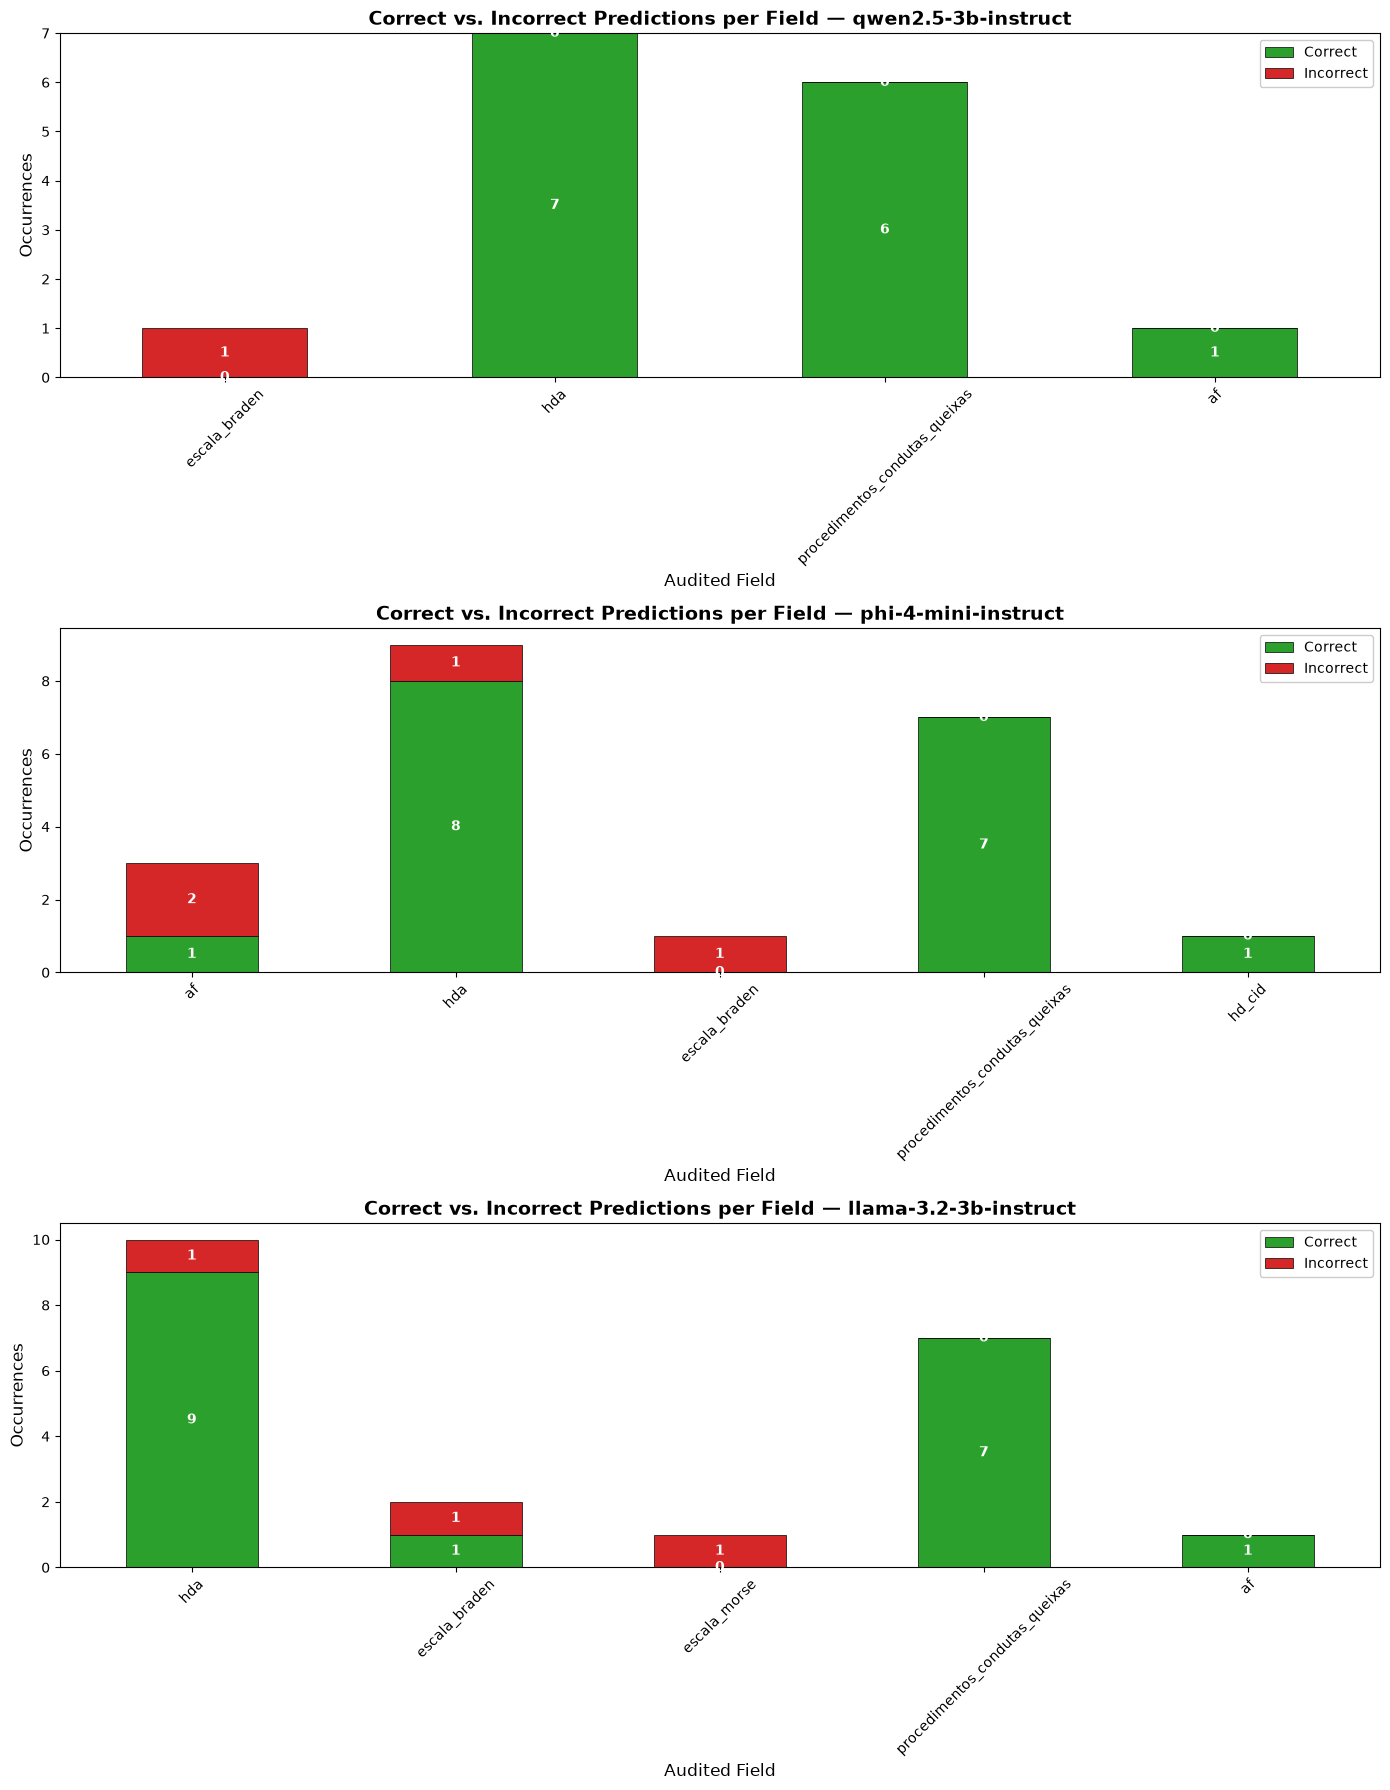

In [13]:
# Accuracy vs. Error per Field — integrated into the notebook flow
# Uses df_metrics, ALL_MODELS and ground_truth already defined in previous cells

# Normalize renamed fields (condutas == procedimentos_condutas_queixas)
df_plot = df_metrics.copy()
df_plot['field'] = df_plot['field'].replace({'condutas': 'procedimentos_condutas_queixas'})

# Keep only fields that exist in the ground truth
valid_fields = ground_truth['field'].unique().tolist()
df_plot = df_plot[df_plot['field'].isin(valid_fields)]

# Boolean hit column: does the prediction match the expected label?
df_plot['correct'] = df_plot['expected'] == df_plot['normalized_classification']

df_hits = df_plot.groupby(['model', 'field'])['correct'].value_counts().unstack(fill_value=0).reset_index()

if True not in df_hits.columns: df_hits[True] = 0
if False not in df_hits.columns: df_hits[False] = 0
df_hits.rename(columns={True: 'Correct', False: 'Incorrect'}, inplace=True)

fig, axes = plt.subplots(len(ALL_MODELS), 1, figsize=(14, 6 * len(ALL_MODELS)))
if len(ALL_MODELS) == 1: axes = [axes]

for i, model in enumerate(ALL_MODELS):
    subset = df_hits[df_hits['model'] == model].set_index('field')
    subset = subset.sort_values(by=['Incorrect', 'Correct'], ascending=[False, False])

    subset[['Correct', 'Incorrect']].plot(
        kind='bar', stacked=True, color=['#2ca02c', '#d62728'],
        ax=axes[i], edgecolor='black', linewidth=0.5
    )

    axes[i].set_title(f"Correct vs. Incorrect Predictions per Field — {model}", fontsize=14, fontweight='bold')
    axes[i].set_ylabel("Occurrences", fontsize=12)
    axes[i].set_xlabel("Audited Field", fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(loc='upper right', framealpha=1)

    for container in axes[i].containers:
        axes[i].bar_label(container, label_type='center', color='white', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


### 8.2 Confusion matrix per model

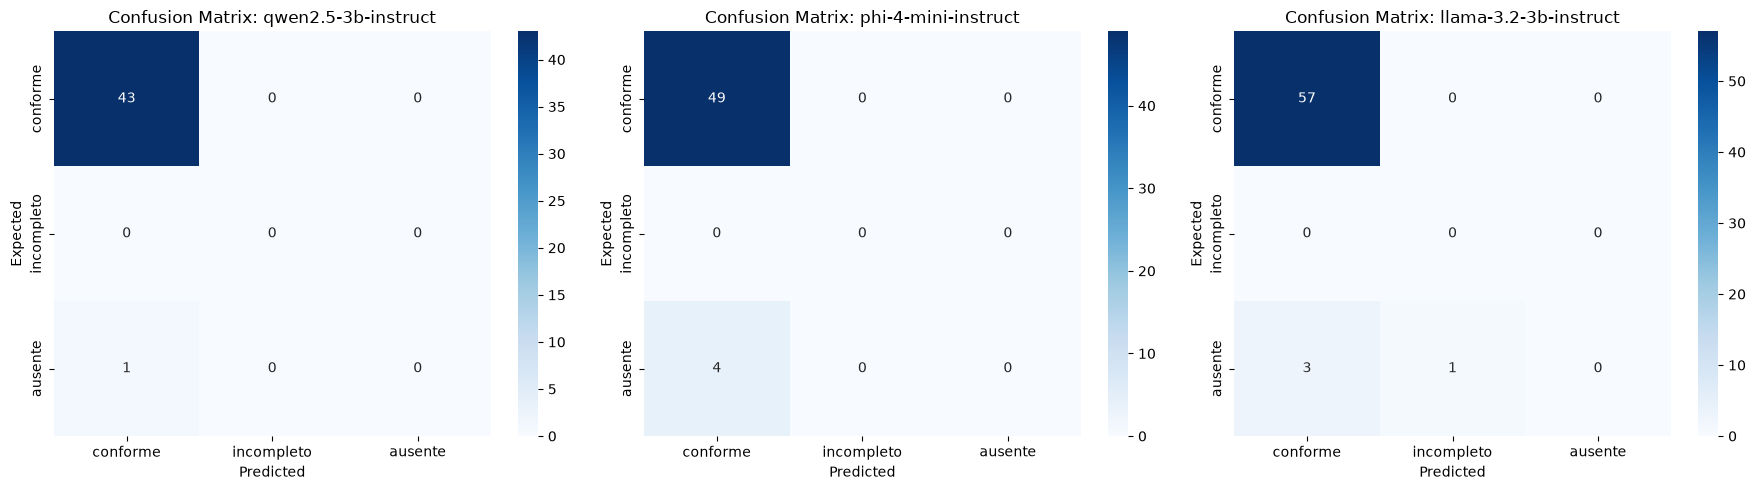

In [14]:
# Mapeia as 3 classes para o gabarito
def get_expected_3way(row):
    if row['expected'] == 'present':
        return 'conforme'
    desc = str(row['description missing']).lower()
    if 'incomplet' in desc or 'prazo' in desc:
        return 'incompleto'
    return 'ausente'

df_metrics['expected_3way'] = df_metrics.apply(get_expected_3way, axis=1)

# Mapeia as 3 classes para a predição da IA
def get_predicted_3way(row):
    status = str(row['status']).lower()
    raw = str(row['raw_value']).lower()
    if 'não se aplica' in status: return 'not_applicable' # ignorado
    if 'não' in status and ('incomplet' in raw or 'incomplet' in status): 
        return 'incompleto'
    if 'não' in status: 
        return 'ausente'
    return 'conforme'

df_metrics['predicted_3way'] = df_metrics.apply(get_predicted_3way, axis=1)

# Lista das 3 classes na ordem correta
labels_3way = ['conforme', 'incompleto', 'ausente']

fig, axes = plt.subplots(1, len(ALL_MODELS), figsize=(6 * len(ALL_MODELS), 5))
if len(ALL_MODELS) == 1:
    axes = [axes]

for i, model in enumerate(ALL_MODELS):
    subset = df_metrics[df_metrics['model'] == model]
    
    if len(subset) == 0:
        continue
        
    y_true = subset['expected_3way']
    y_pred = subset['predicted_3way']
    
    cm = confusion_matrix(y_true, y_pred, labels=labels_3way)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], 
                xticklabels=labels_3way, yticklabels=labels_3way)
    axes[i].set_title(f"Confusion Matrix: {model}")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Expected")

plt.tight_layout()
plt.show()


## 9. Latency metrics (critical for running on CPU / a notebook without a GPU)

In [15]:
# Time is measured per endpoint call (all fields for that record), not per individual field
df_times = df_raw.drop_duplicates(subset=['model', 'repetition', 'record'])[
    ['model', 'record', 'time_seconds']
]

latency_summary = df_times.groupby('model')['time_seconds'].agg(
    mean='mean', std='std', min='min', max='max'
).reset_index()

latency_summary.to_csv(RESULTS_DIR / 'latency_metrics.csv', index=False)
latency_summary


,model,mean,std,min,max
0,llama-3.2-3b-instruct,6.409530,0.0,6.409530,6.409530
1,phi-4-mini-instruct,10.063691,0.0,10.063691,10.063691
2,qwen2.5-3b-instruct,5.951464,0.0,5.951464,5.951464


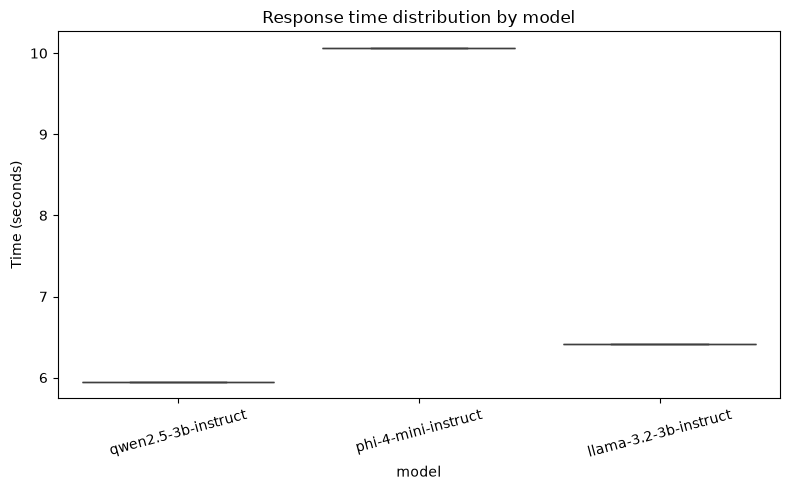

In [16]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_times, x='model', y='time_seconds')
plt.title('Response time distribution by model')
plt.ylabel('Time (seconds)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'latency_boxplot.png', dpi=150)
plt.show()


## 10. Technical error rate per model

Separates execution failures (timeout, invalid JSON, endpoint down) from content errors — important so a model isn't penalized for infrastructure instability.

In [17]:
error_rate_df = df_raw.groupby('model').apply(
    lambda g: pd.Series({
        'total_calls': g['record'].nunique(),
        'calls_with_error': g[g['execution_error'].notna()]['record'].nunique(),
    })
).reset_index()

error_rate_df['error_rate_pct'] = (error_rate_df['calls_with_error'] / error_rate_df['total_calls'] * 100).round(2)
error_rate_df


,model,total_calls,calls_with_error,error_rate_pct
0,llama-3.2-3b-instruct,11,0,0.0
1,phi-4-mini-instruct,11,0,0.0
2,qwen2.5-3b-instruct,11,0,0.0


## 11. Final consolidated table — summary for the thesis

In [18]:
final_summary = df_quality_summary.merge(latency_summary, on='model').merge(
    error_rate_df[['model', 'error_rate_pct']], on='model'
)
final_summary = final_summary.round(3)
final_summary.to_csv(RESULTS_DIR / 'final_summary.csv', index=False)
final_summary


,model,n_samples,precision (Qualidade),recall (Qualidade),f1 (Qualidade),precision (Presença),recall (Presença),f1 (Presença),mean,std,min,max,error_rate_pct
0,qwen2.5-3b-instruct,44,0.977,1.0,0.989,0.977,1.0,0.989,5.951,0.0,5.951,5.951,0.0
1,phi-4-mini-instruct,53,0.925,1.0,0.961,0.925,1.0,0.961,10.064,0.0,10.064,10.064,0.0
2,llama-3.2-3b-instruct,61,0.950,1.0,0.974,0.950,1.0,0.974,6.410,0.0,6.410,6.410,0.0


---
## Manual next steps

1. Review `quality_metrics_by_field.csv` to identify which fields perform worst per model
2. Manually validate a sample of the error cases (`normalized_classification != expected`) to confirm whether they are real model failures or issues in the synthetic ground truth
3. Use `final_summary.csv` and the generated charts as the basis for the thesis tables/figures
4. To formally measure consistency/determinism, increase `N_REPETITIONS` to 3-5 and compute the agreement rate between repetitions